Notes for the last class of visualization. Mainly will be adding in code, but anything else will be written as necessary. Note that most of the notes I have are written on the slides. 

Activity, diagram of ship: Ship uses specific numbers, underlines key words etc. 

In [1]:
# Seaborn is a data viz package built on top of matplotlib.
# It handles semantic mapping (variable → visual element) more automatically.
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

In [2]:
# Contains restaurant tip info: meal time, party size, gender, total bill, tip amount.
tips = sns.load_dataset("tips")
print(tips)

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


<Axes: xlabel='total_bill', ylabel='tip'>

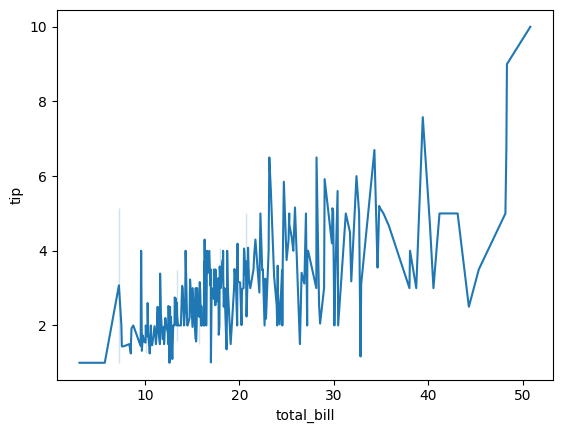

In [3]:
# Plot tip amount vs total bill as a simple line plot.
sns.lineplot(data=tips,   # choose our dataset
             x='total_bill',  # define our x variable
             y='tip')         # define our y variable

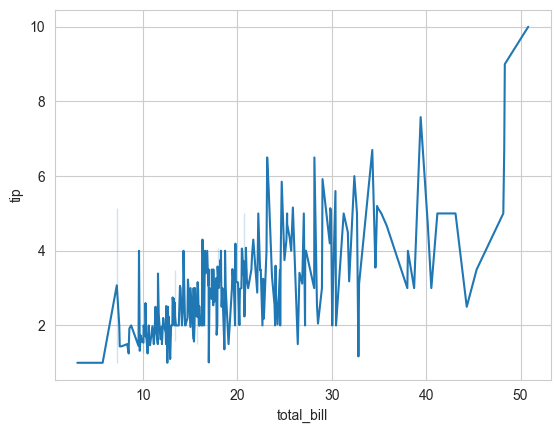

In [5]:
sns.lineplot(data=tips,   
             x='total_bill',  
             y='tip')  
sns.set_style('whitegrid')

[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

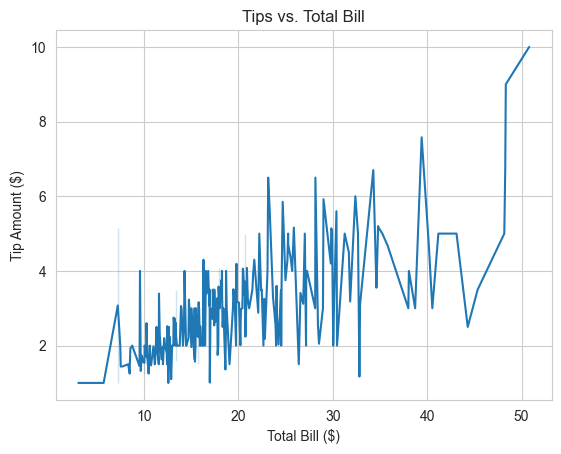

In [6]:
#Adding titles and axis labels to above plot.
tipgraph = sns.lineplot(data=tips,
                        x='total_bill',
                        y='tip')

tipgraph.set(title='Tips vs. Total Bill',
             xlabel='Total Bill ($)',
             ylabel='Tip Amount ($)')

[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

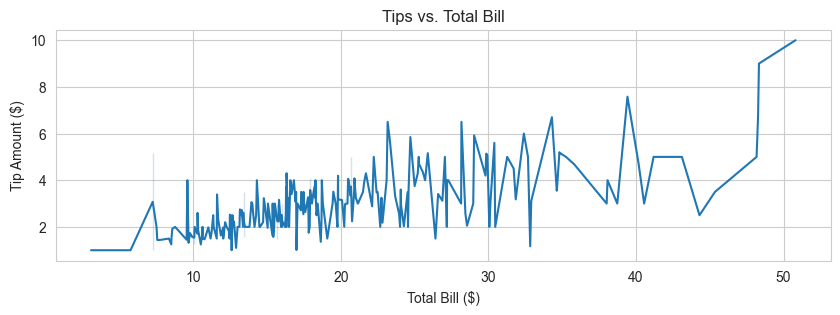

In [12]:
# Modify figure size
fig = plt.subplots(figsize=(10, 3))

tipgraph = sns.lineplot(data=tips,
                        x='total_bill',
                        y='tip')
tipgraph.set(title='Tips vs. Total Bill',
             xlabel='Total Bill ($)',
             ylabel='Tip Amount ($)')



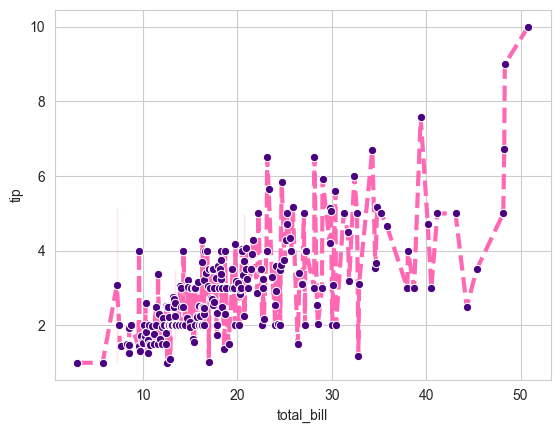

In [13]:
# Customize colour, line style, line width, marker style, and marker fill colour.
tipgraph = sns.lineplot(data=tips,
                        x='total_bill',
                        y='tip',
                        color='hotpink',         # line colour
                        linestyle='--',           # dashed line
                        linewidth=3,              # line thickness
                        marker='o',               # circle markers at each data point
                        markerfacecolor='indigo') # fill colour of markers

[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

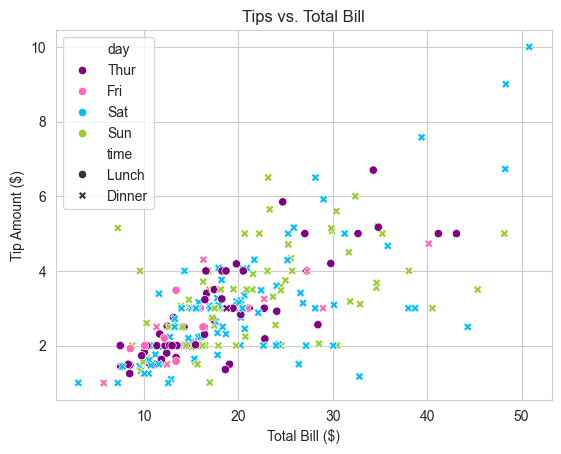

In [14]:
# Map additional variables to visual properties: 'hue' → colour, 'style' → marker shape.
# This is where seaborn really shines over base matplotlib.
tipgraph = sns.scatterplot(data=tips,
                           x='total_bill',
                           y='tip',
                           style='time',          # marker shape encodes meal time (Lunch/Dinner)
                           hue='day',             # colour encodes day of the week
                           palette=['purple',
                                    'hotpink',
                                    'deepskyblue',
                                    'yellowgreen'])

tipgraph.set(title='Tips vs. Total Bill',
             xlabel='Total Bill ($)',
             ylabel='Tip Amount ($)')

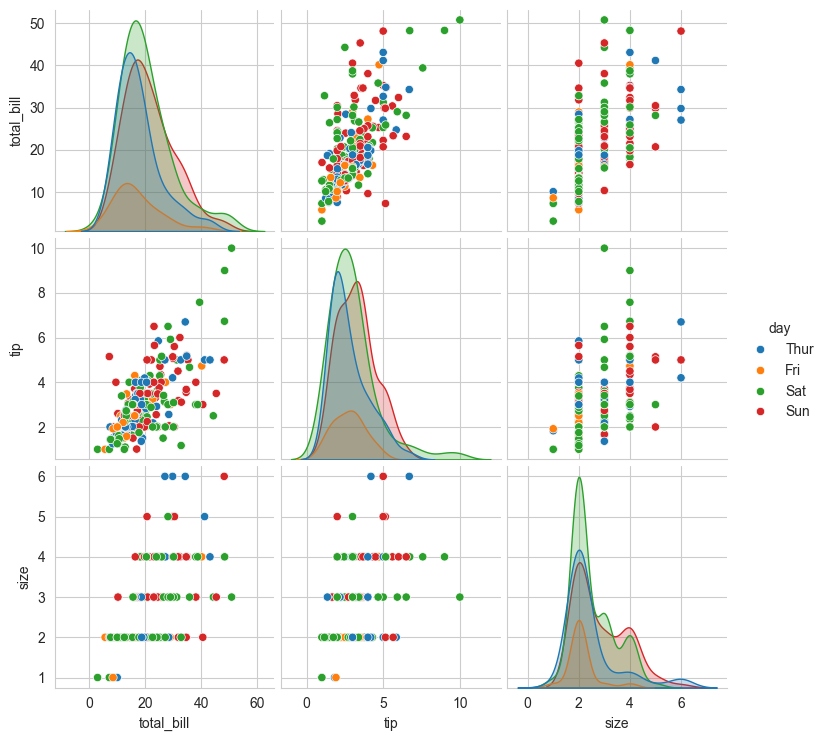

In [15]:
# 'hue' colour-codes by day of the week.
sns.pairplot(
    data=tips,
    hue='day')

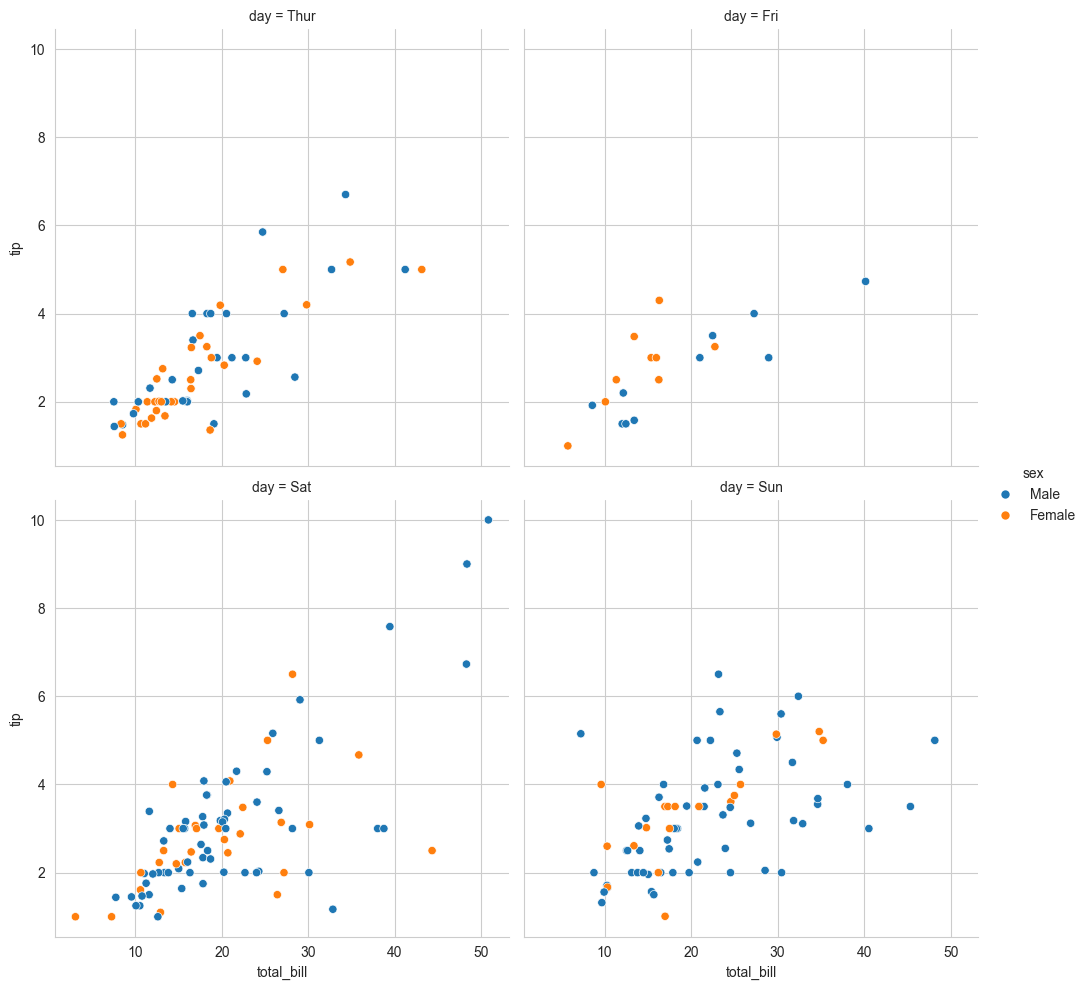

In [16]:
daysplot = sns.relplot(
    data=tips,
    x="total_bill",   # x-axis: total bill amount
    y="tip",          # y-axis: tip amount
    hue="sex",        # colour encodes customer gender
    col="day",        # creates a separate panel for each day
    kind="scatter",   # scatter plot (vs. 'line')
    col_wrap=2)       # wrap panels into 2 columns

Getting more into the Interactive plots using plotly. PLUS doing the case study plus activities

The right data set is more informative and easier to understand if you know how to work it the active visualization. 

Activity: types of change.

When you search a new word, the changes are mostly immediate the data points fully remap with no preserved association to the previous state. Within a single search though, spatial elements like the y-axis categories and x-axis scale stay constant while only the dot positions change, which feels more transitional. If I were redesigning it, I'd add a second search field so you could compare two words side by side, which would make it more identity-preserving.

In [17]:
# 'graph_objects' (go) is the main Plotly module for building figures.
# Create some sample data using One Piece characters.
import plotly.graph_objects as go  # 'go' is short for 'graph objects'

x1 = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y1 = np.array([110, 180, 240, 99, 220])

In [18]:
graph = go.Figure()  # initialize an empty figure

# Add a bar chart trace with our data
graph.add_trace(go.Bar(x=x1, y=y1))

# Add axis titles and a main title to the layout
graph.update_layout(
    title="Pirate Scores",
    xaxis_title="Pirates",
    yaxis_title="Score")

graph.show()  # render the interactive figure

In [19]:
graph.write_html("/Users/ethanchurchill/Desktop/Data Science visualization/pirategraph.html")

In [ ]:
# The 'marker' dict controls point appearance. note updated as class continued.
graph = go.Figure()

graph.add_trace(go.Scatter(
    x=x1,
    y=y1,
    mode='markers',           # display as points (not lines)
    marker=dict(
        size=15,              # point size
        color='hotpink',      # point fill colour
        opacity=1,            # transparency (0 = invisible, 1 = fully opaque)
        line=dict(
            width=5,          # width of point outline
            color='purple')   # colour of point outline
    )))

graph.update_layout(
    title='Interactive Pirate Plot',
    xaxis_title='Pirates',
    yaxis_title='Scores',
    width=500,
    height=500)

graph.show()

Wordcloud and Venn Diagrams time

In [21]:
# Import WordCloud and load a sample CSV of movie quotes from GitHub.
from wordcloud import WordCloud

df = pd.read_csv(
    "https://raw.githubusercontent.com/prasertcbs/basic-dataset/master/movie_quotes.csv",
    on_bad_lines='skip')  # skip any rows that don't parse correctly

df

,quote,movie,type,year
0,"Do, or do not. There is no try.",Star Wars: Episode V - The Empire Strikes Back,movie,1890
1,Listen to them. Children of the night. What mu...,Dracula,movie,1931
2,It's alive! It's alive!,Frankenstein,movie,1931
3,"Oh, no, it wasn't the airplanes. It was Beauty...",King Kong,movie,1933
4,"Magic Mirror on the wall, who is the fairest o...",Snow White and the Seven Dwarves,movie,1937
...,...,...,...,...
727,I didn't know if you were lost. Stick with me....,Us,movie,2019
728,This guy's awesome! He's holding his own while...,Dragon Ball Super: Broly,movie,2019
729,"Murder is murder, it don’t matter who you are.",Black and Blue,movie,2019
730,You know what a lion is? A lion is a strong an...,Between Two Ferns: The Movie,movie,2019


(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

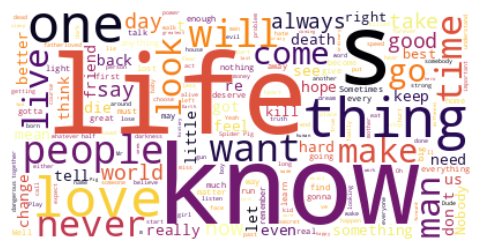

In [22]:
# Join all quote text from every row into a single string
text = " ".join(each for each in df.quote)

# Generate the wordcloud image
wordcloud = WordCloud(
    background_color="white",
    colormap='inferno'      # colour palette for the words
).generate(text)

# Use matplotlib to display the wordcloud image in a figure
fig, ax = plt.subplots(figsize=(7, 3))
ax.imshow(wordcloud,                     # render the image on the axes
          interpolation='bilinear')      # smooths the rendering of the image
ax.axis("off")                           # hide the x/y axes

/Users/ethanchurchill/Desktop/Data Science visualization/visualization-env/lib/python3.11/site-packages/matplotlib_venn/_util.py:32: UserWarning:

venn2_unweighted is deprecated. Use venn2 with the appropriate layout_algorithm instead.



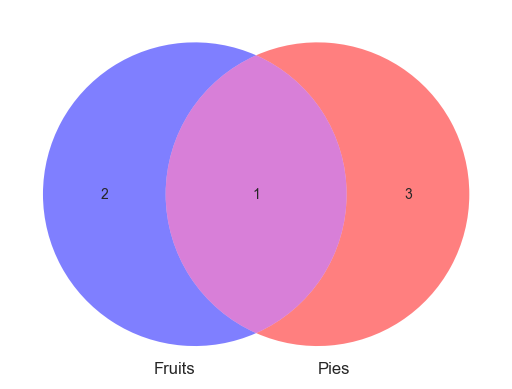

In [24]:
# matplotlib_venn extends matplotlib with Venn diagram support.
# Import the unweighted version (circles are equal size regardless of set size).
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted

# Define two sets to compare
A = set(["apple", "banana", "watermelon"])           # fruits
B = set(["pumpkin", "blueberry", "apple", "key lime"]) # pie fillings

diagram = venn2_unweighted(
    [A, B],
    set_labels=('Fruits', 'Pies'),  # labels below each circle
    set_colors=("blue", "red"),     # fill colour for each circle
    alpha=0.5)                       # transparency of the circle fills

plt.show()

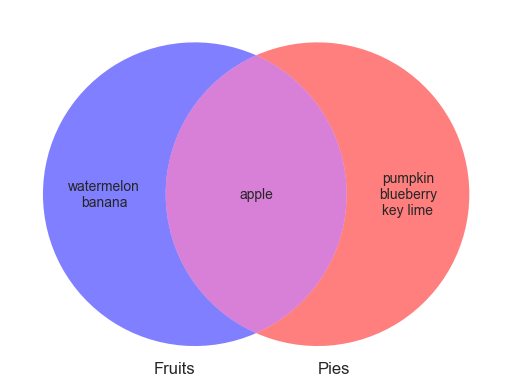

In [26]:
# Replace the default counts with the actual item names.
# Region IDs follow the documentation convention:
#   '10' = only in A (left circle)
#   '11' = in both A and B (intersection)
#   '01' = only in B (right circle)
diagram = venn2_unweighted(
    [A, B],
    set_labels=('Fruits', 'Pies'),  # labels below each circle
    set_colors=("blue", "red"),     # fill colour for each circle
    alpha=0.5)                       # transparency of the circle fills

diagram.get_label_by_id("10").set_text("\n".join(A - B))  # items only in Fruits
diagram.get_label_by_id("11").set_text("\n".join(A & B))  # items in both sets
diagram.get_label_by_id("01").set_text("\n".join(B - A))  # items only in Pies


plt.show()